In [56]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

(100, 1)
(100,)


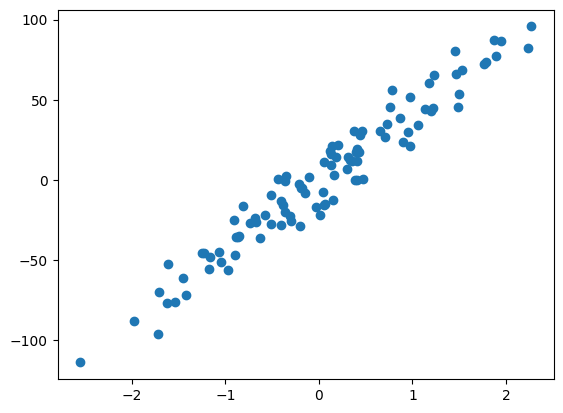

In [57]:
np.random.seed(0)  # pour toujours reproduire le même dataset

x, y = make_regression(n_samples=100, n_features=1, noise=10)

plt.scatter(x, y)  # afficher les résultats. X en abscisse et y en ordonnée

# NB: vérifier les dimensions de x et y.
print(x.shape)
print(y.shape)

In [58]:
y = y.reshape(y.shape[0], 1)
print(y.shape)

(100, 1)


In [59]:
np.random.seed(0)  # pour produire toujours le même vecteur theta aléatoire
theta = np.random.randn(2, 1)
theta

array([[1.76405235],
       [0.40015721]])

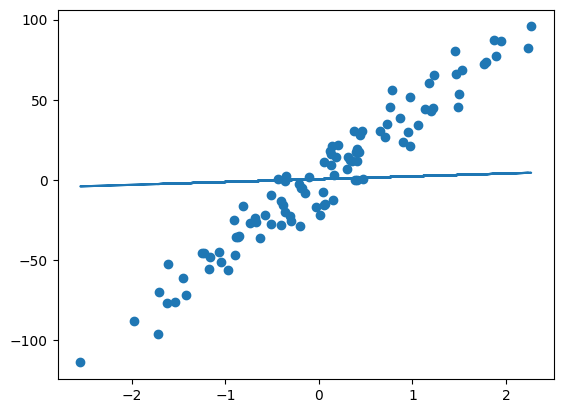

In [60]:
def model(X, theta):
    return X.dot(theta)  # Calcul du modèle linéaire: X * theta

# Affichage des données et du modèle
plt.scatter(x, y)  # Nuage de points des données réelles
plt.plot(x, model(X, theta))  # Tracé de la droite du modèle linéaire
plt.show()  # Afficher le graphique (ajouté pour complétude)

In [61]:
def cost_function(X, y, theta):
    m = len(y)  # Nombre d'exemples d'entraînement
    return 1/(2*m) * np.sum((model(X, theta) - y)**2)  # Calcul de la fonction de coût

# Calcul et affichage du coût initial
cost_function(X, y, theta)

np.float64(905.6306841935502)

In [62]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)  # Calcul du gradient

def gradient_descent(X, y, theta, learning_rate, n_iterations):
    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta)  # Mise à jour des paramètres
    return theta

In [63]:
# Paramètres d'apprentissage
n_iterations = 1000
learning_rate = 0.01

# Entraînement du modèle
theta_final = gradient_descent(X, y, theta, learning_rate, n_iterations)
print(theta_final)  # Affiche les paramètres optimisés (a, b)


[[42.61765864]
 [-0.81309274]]


In [64]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    cost_history = np.zeros(n_iterations)  # Création d'un tableau pour stocker l'évolution du coût

    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta)  # Mise à jour des paramètres
        cost_history[i] = cost_function(X, y, theta)  # Enregistrement du coût à l'itération i

    return theta, cost_history  # Retourne les paramètres optimisés ET l'historique des coûts

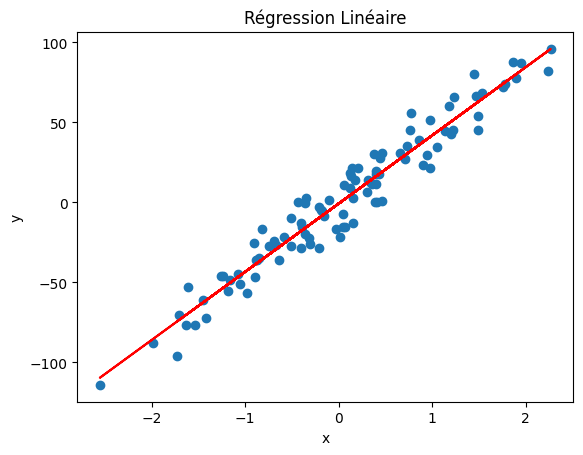

In [65]:
# Prédictions avec les paramètres optimisés
predictions = model(X, theta_final)

# Visualisation
plt.scatter(x, y)  # Données réelles
plt.plot(x, predictions, c='r')  # Droite de régression (en rouge)
plt.xlabel('x')  # Ajout des labels (recommandé)
plt.ylabel('y')
plt.title('Régression Linéaire')
plt.show()

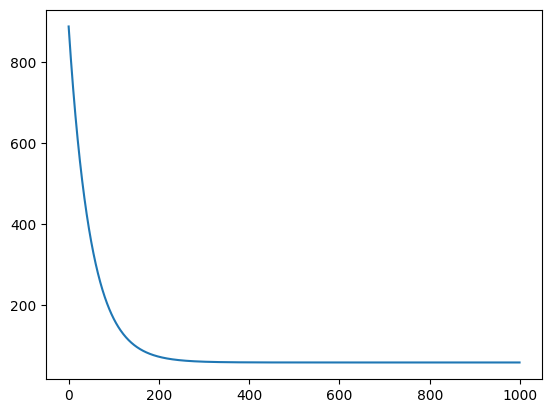

In [66]:
theta_final,cost_history= gradient_descent(X, y, theta, learning_rate=0.01, n_iterations=1000)
plt.plot(range(n_iterations), cost_history)

In [67]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    cost_history = np.zeros(n_iterations)  # Création d'un tableau pour stocker l'évolution du coût

    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta)  # Mise à jour des paramètres
        cost_history[i] = cost_function(X, y, theta)  # Enregistrement du coût à l'itération i

    return theta, cost_history  # Retourne les paramètres optimisés ET l'historique des coûts
    plt.plot(range(n_iterations), cost_history)

In [68]:
def coef_determination(y, pred):
    u = ((y - pred)**2).sum()  # Somme des carrés des résidus
    v = ((y - y.mean())**2).sum()  # Somme des carrés totaux
    return 1 - u/v  # Formule du R²
coef_determination(y, predictions)

np.float64(0.9417294706504984)